# **Import libraries**

In [2]:
# !pip install dtreeviz
# !pip install lime

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
# from dtreeviz.trees import *
from dtreeviz import model
import warnings
import logging
import math
import lime

In [4]:
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [5]:
warnings.filterwarnings("ignore")

In [6]:
sns.set_palette('viridis')

# **Load Dataset**

## Dataset 1

[Chosen Dataset](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)

In [7]:
df_pd = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "kukuroo3/body-performance-data",
  "bodyPerformance.csv"
)

Using Colab cache for faster access to the 'body-performance-data' dataset.


In [8]:
df_pd['gender'] = pd.get_dummies(df_pd['gender'], drop_first=True, dtype=int)

In [9]:
lbl_encoder = LabelEncoder()
df_pd['class'] = lbl_encoder.fit_transform(df_pd['class'])

In [9]:
for clas in range(len(lbl_encoder.classes_)):
  print(clas, lbl_encoder.inverse_transform([clas]))

0 ['A']
1 ['B']
2 ['C']
3 ['D']


In [10]:
df_pd.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [10]:
numeric_cols = df_pd.columns.copy().drop(['gender', 'class'])

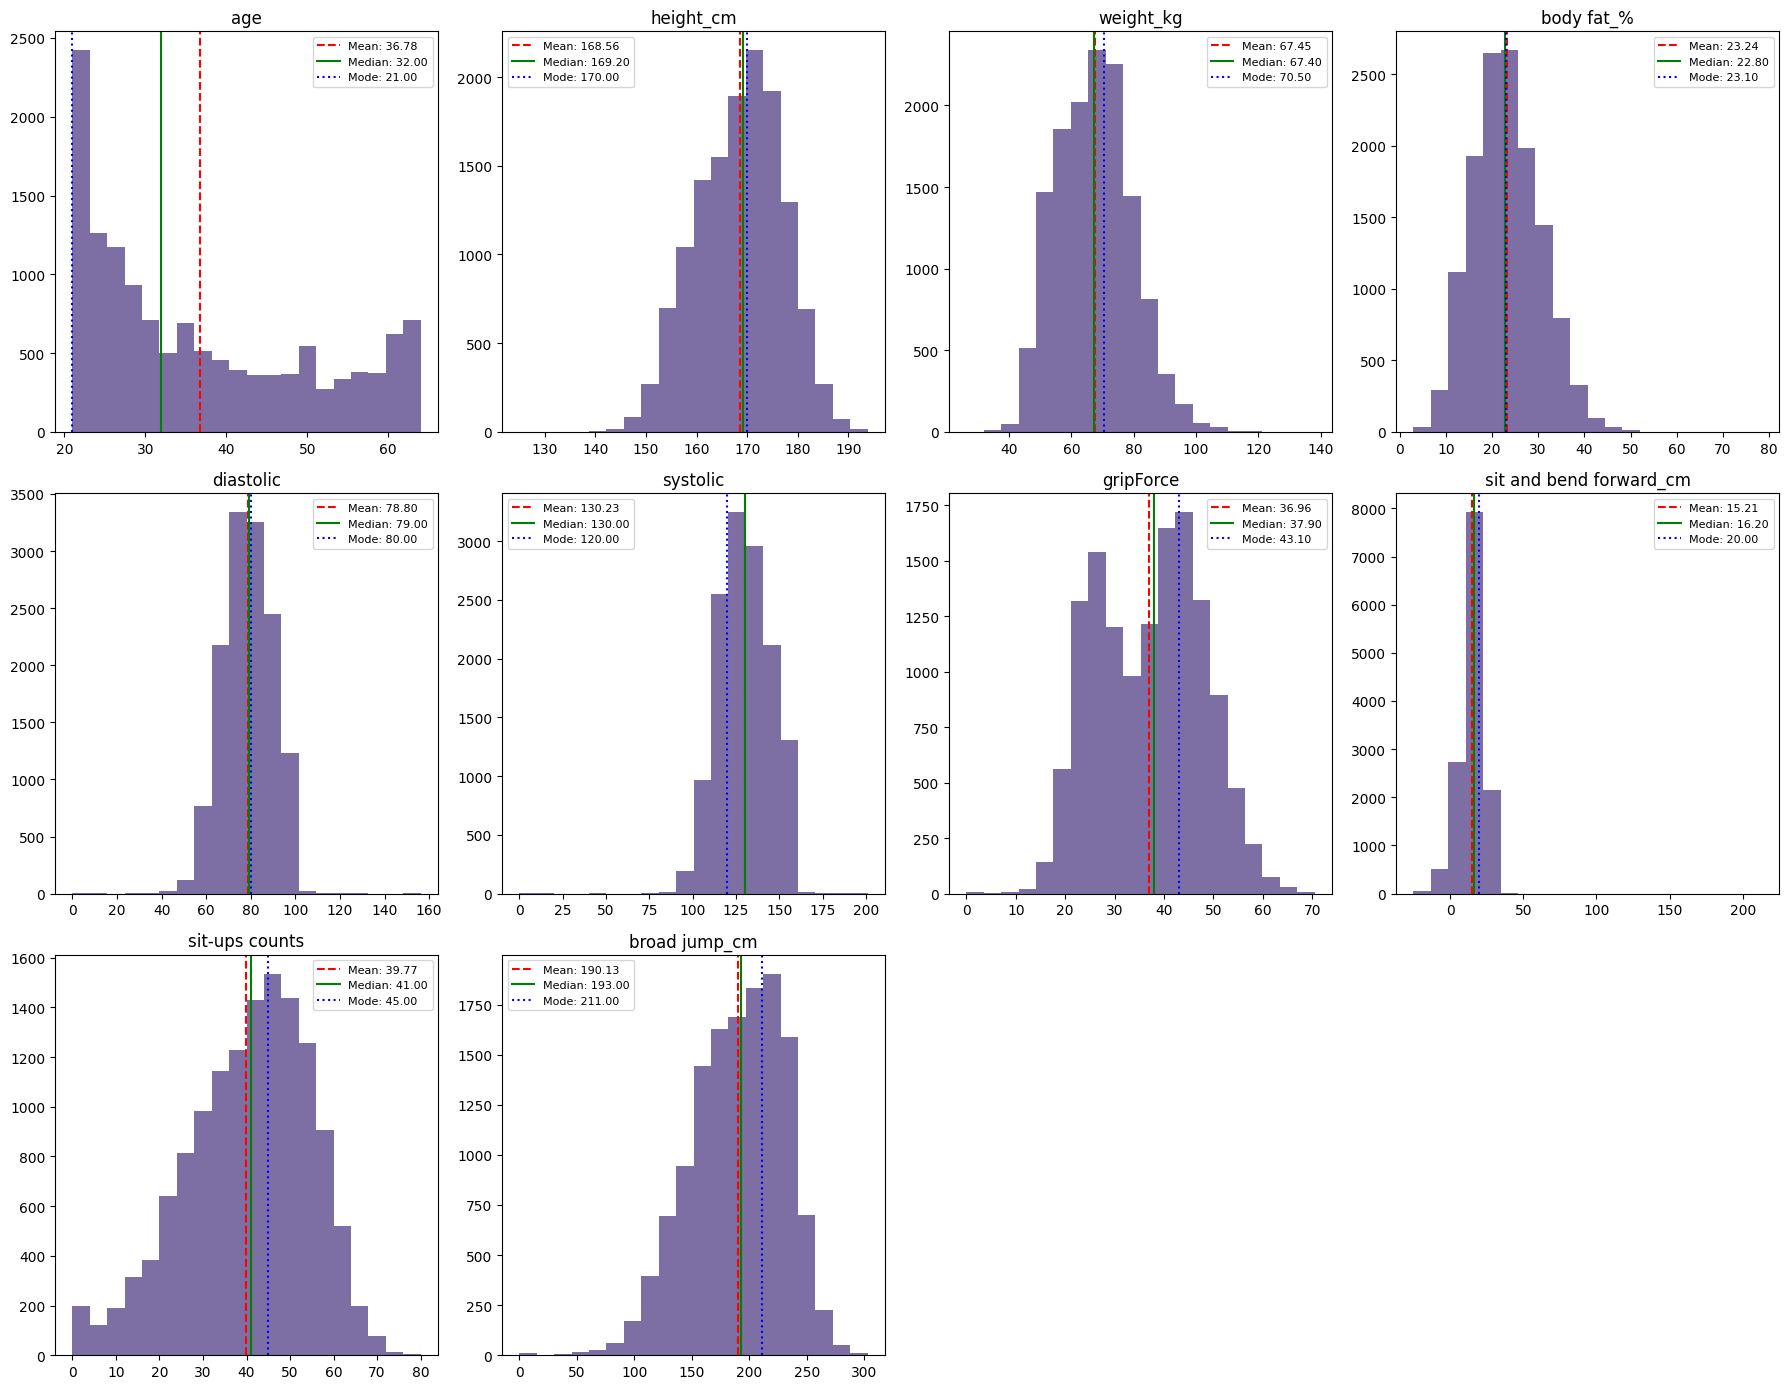

In [12]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axs = axs.flatten()

for col, ax in zip(numeric_cols, axs):
    data = df_pd[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

The majority of data is normally distributed, but some features contain outliers - sit and bend forward, body fat, and height.

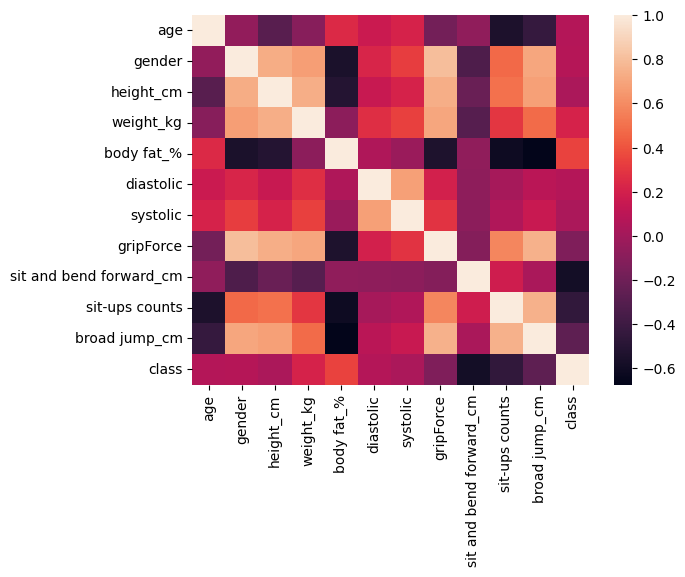

In [13]:
sns.heatmap(df_pd.corr())
plt.show()

Body fat, sit and bend forward, and sit-ups counts are the most correlated features with class.

## Dataset 2

[Chosen Dataset](https://www.kaggle.com/datasets/neuromusic/avocado-prices?select=avocado.csv)

In [24]:
df_emt = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wkirgsn/electric-motor-temperature",
  "measures_v2.csv"
)

100%|██████████| 117M/117M [00:02<00:00, 55.9MB/s]

Extracting zip of measures_v2.csv...


In [15]:
df_emt.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [25]:
df_emt.drop(['profile_id'], axis=1, inplace=True)

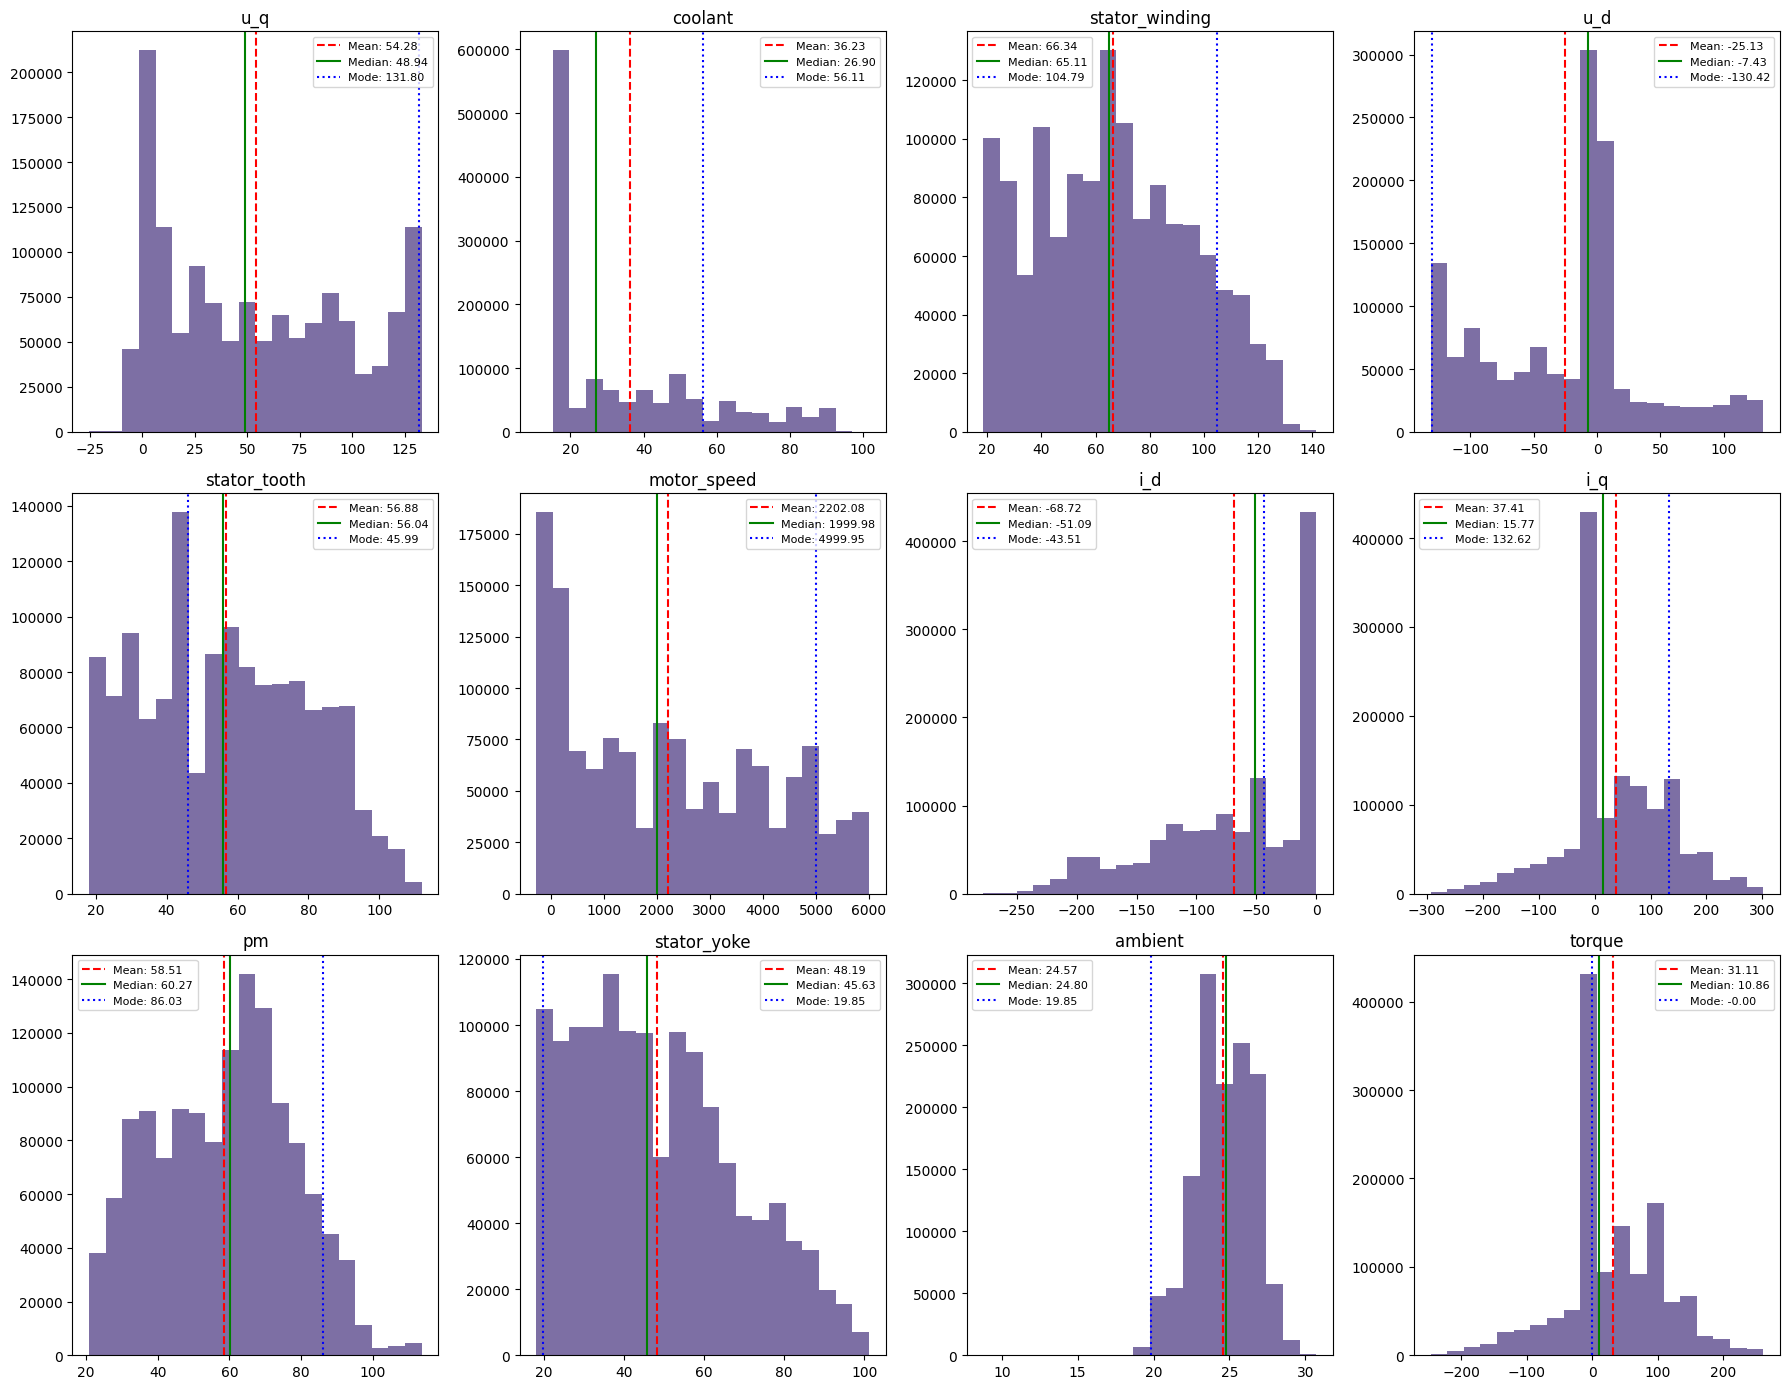

In [17]:
n_cols = 4
n_rows = int(np.ceil(len(df_emt.columns) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axs = axs.flatten()

for col, ax in zip(df_emt.columns, axs):
    data = df_emt[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(df_emt.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

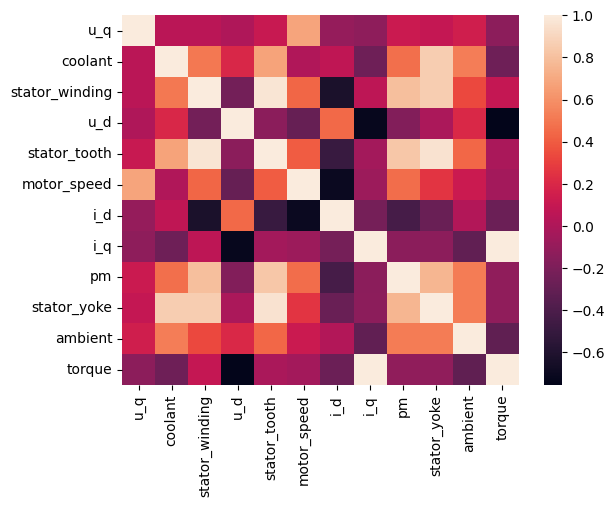

In [18]:
sns.heatmap(df_emt.corr())
plt.show()

pm has the highest correlation with stator_winding, stator_tooth, and stator_yoke -> features related to stator.

# **Model Interpretation**

## **Linear Regression**

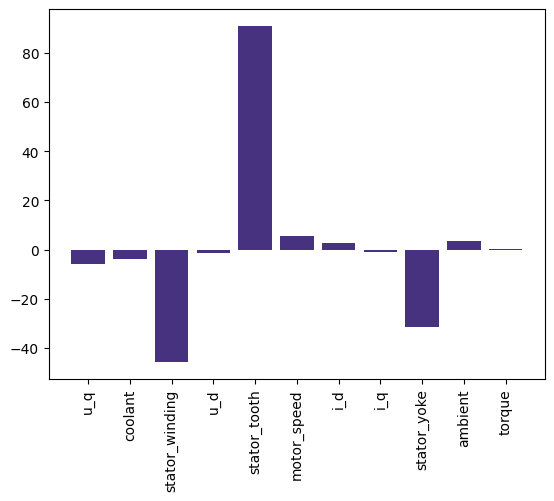

In [19]:
lr = LinearRegression()

X = df_emt.drop('pm', axis=1)
y = df_emt['pm']

std_scaler = StandardScaler().set_output(transform='pandas')
X = std_scaler.fit_transform(X)

lr.fit(X, y)

plt.bar(x=range(len(X.columns)), height=lr.coef_)
plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.show()

i_q, u_d, and torque give almost no information. The most important feature turned out to be features related to the stator - stator_tooth, stator_winding, stator_yoke.

This reinforces the idea that the most correlated features(as we saw in the heatmap) are the most important.

## **Decision Tree**

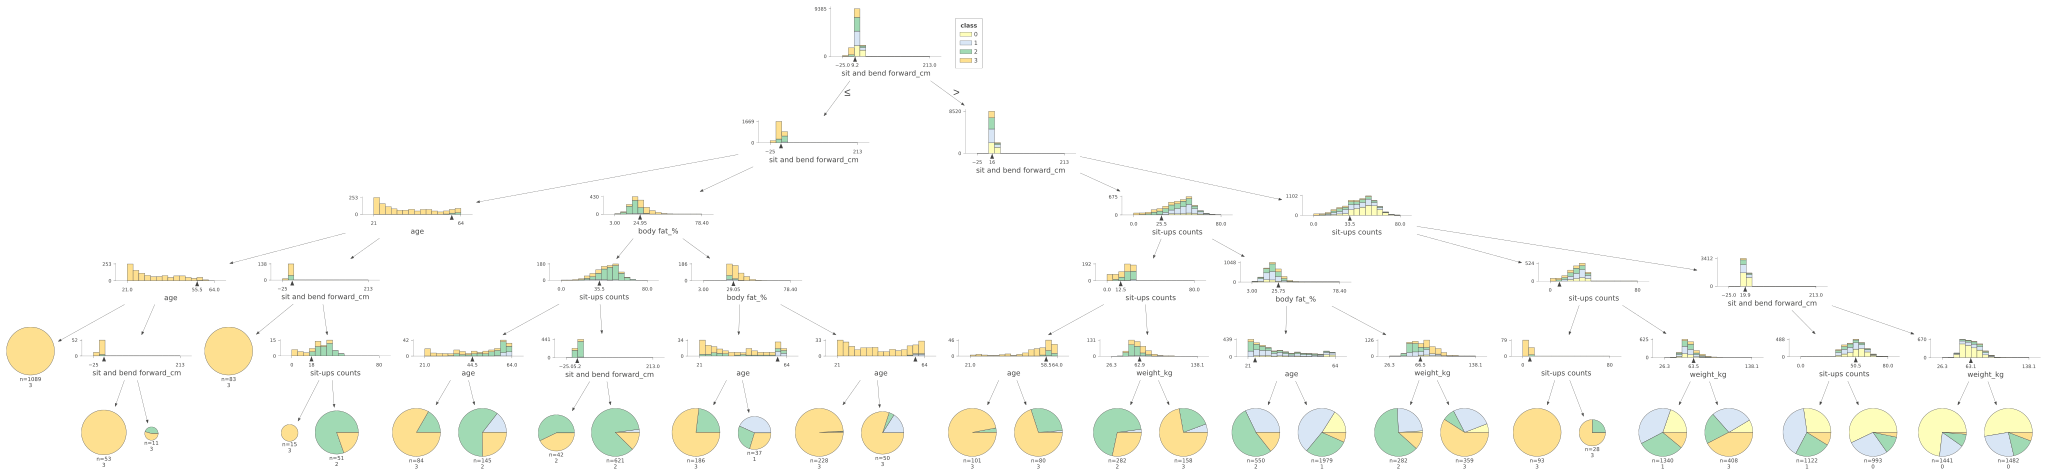

In [11]:
X = df_pd.drop('class', axis=1)
y = df_pd['class']
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X, y)
class_names = sorted(df_pd['class'].unique())

viz_model = model(
  clf,
  X,
  y,
  target_name='class',
  feature_names=X.columns,
  class_names=class_names)

viz_model.view()

From this graph we see that sit and bend forward is the most important feature for classification(explaining the majority of entropy). Next comes body_fat and sit-ups counts, then age and weight.

## **Split Datasets**

In [26]:
X = df_emt.drop('pm', axis=1)
y = df_emt['pm']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X = df_pd.drop('class', axis=1)
y = df_pd['class']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

## **Regression Dataset**

In [27]:
estimators = [LinearRegression(),
              KNeighborsRegressor(),
              RandomForestRegressor(max_depth=7, random_state=42),
              DecisionTreeRegressor(max_depth=7, random_state=42)]

In [28]:
scores = []


for estimator in estimators:

  estimator.fit(X_train1, y_train1)
  y_pred = estimator.predict(X_test1)

  mse = mean_squared_error(y_test1, y_pred)
  mae = mean_absolute_error(y_test1, y_pred)
  rmse = root_mean_squared_error(y_test1, y_pred)
  print(estimator.__class__.__name__)
  scores.append([estimator.__class__.__name__, mse, mae, rmse])

pd.DataFrame(scores, columns=['Estimator', 'MSE', 'MAE', 'RMSE']).head()

LinearRegression
KNeighborsRegressor
RandomForestRegressor
DecisionTreeRegressor


,Estimator,MSE,MAE,RMSE
0,LinearRegression,52.534094,5.429973,7.248041
1,KNeighborsRegressor,13.853131,1.531152,3.721979
2,RandomForestRegressor,43.675512,4.659961,6.608745
3,DecisionTreeRegressor,46.513081,4.830157,6.820050


In [25]:
df_scores = pd.DataFrame(scores, columns=['Estimator', 'MSE', 'MAE', 'RMSE'])

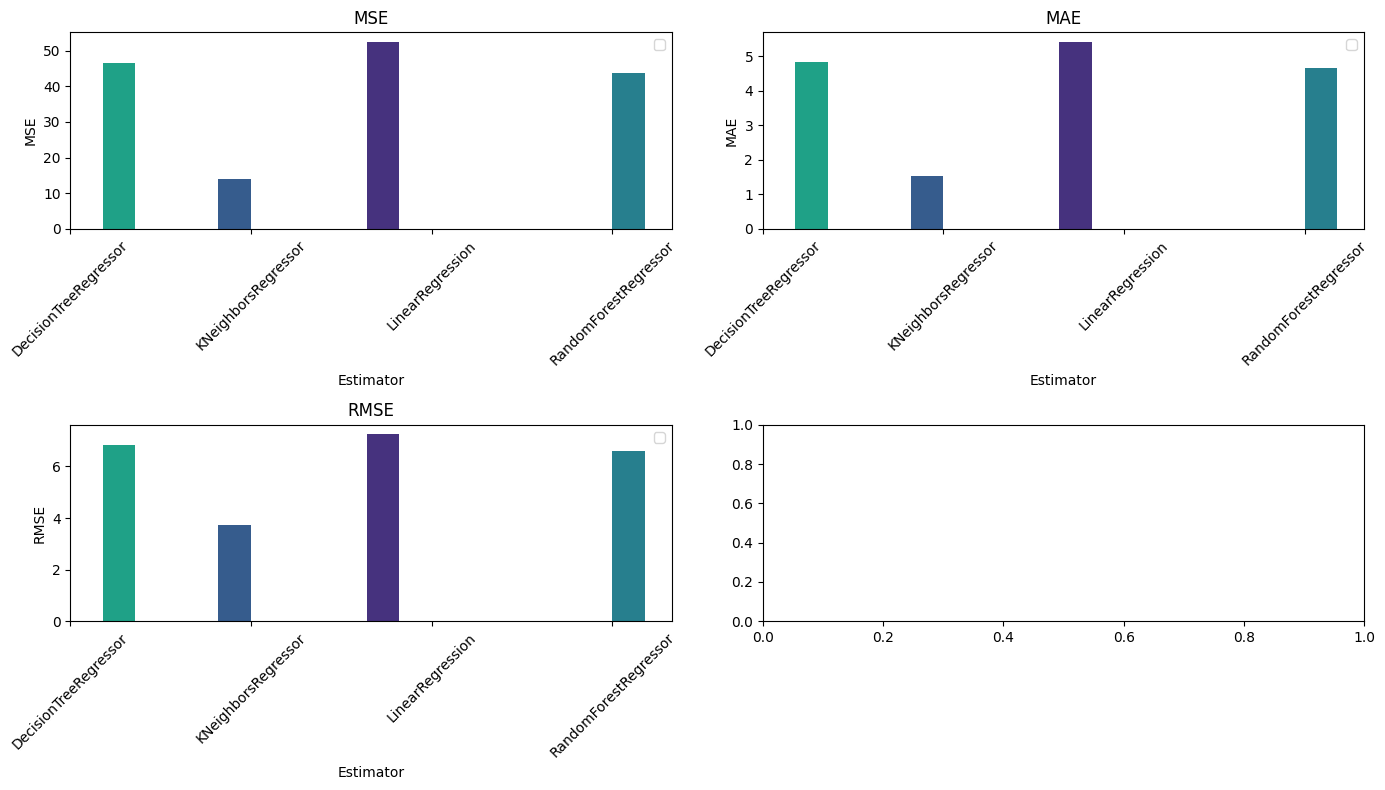

In [26]:
metrics = df_scores.columns.drop(['Estimator'])

n_metrics = len(metrics)
n_cols = 2
n_rows = math.ceil(n_metrics / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 8))
axs = axs.flatten()

for j, metric in enumerate(metrics):

    pivot = df_scores.pivot(index="Estimator", columns=['MSE', 'MAE', 'RMSE'], values=metric)

    estims = pivot.index
    classes = pivot.columns

    x = np.arange(len(estims))
    width = 0.18

    ax = axs[j]

    for i, c in enumerate(classes):
        ax.bar(x + i*width, pivot[c], width)

    ax.set_xticks(x + width*(len(classes)-1)/2)
    ax.set_xticklabels(estims, rotation=45)
    ax.set_xlabel("Estimator")
    ax.set_ylabel(metric)
    ax.set_title(metric)

    ax.legend()

plt.tight_layout()
plt.show()

As we see, the minimal errors are achieved by KNeighborsRegressor(due to closeness of results).

LinearRegression shows the maximal error, mabe to non-liniar relationship between features and target(but neighboring, judging by KNeighbors)

## **Classification Dataset**

In [15]:
mm_scaler = MinMaxScaler().set_output(transform='pandas')

X_train2 = mm_scaler.fit_transform(X_train2)
X_test2 = mm_scaler.transform(X_test2)

In [16]:
estimators2 = [LogisticRegression(random_state=42),
              GaussianNB(),
              KNeighborsClassifier(),
              RandomForestClassifier(random_state=42),
              DecisionTreeClassifier(random_state=42),
              BernoulliNB()
              ]

In [17]:
scores = []


for estimator in estimators2:

  estimator.fit(X_train2, y_train2)
  y_pred = estimator.predict(X_test2)

  acc = accuracy_score(y_test2, y_pred)
  prec = precision_score(y_test2, y_pred, average=None)
  recall = recall_score(y_test2, y_pred, average=None)
  f1_sc = f1_score(y_test2, y_pred, average=None)

  for i, score in enumerate(zip(prec, recall, f1_sc)):
    scores.append([estimator.__class__.__name__, i, acc, score[0], score[1], score[2]])


mult_nb = MultinomialNB()
mult_nb.fit(X_train2, y_train2)
y_pred = mult_nb.predict(X_test2)

acc = accuracy_score(y_test2, y_pred)
prec = precision_score(y_test2, y_pred, average=None)
recall = recall_score(y_test2, y_pred, average=None)
f1_sc = f1_score(y_test2, y_pred, average=None)

for i, score in enumerate(zip(prec, recall, f1_sc)):
  scores.append([mult_nb.__class__.__name__, i, acc, score[0], score[1], score[2]])


df_scores = pd.DataFrame(scores, columns=['Estimator', 'Class', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_scores

,Estimator,Class,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0,0.604703,0.651341,0.744526,0.694823
1,LogisticRegression,1,0.604703,0.443038,0.370091,0.403292
2,LogisticRegression,2,0.604703,0.519936,0.501538,0.510572
3,LogisticRegression,3,0.604703,0.752793,0.790323,0.771102
4,GaussianNB,0,0.555431,0.604434,0.756204,0.671855
5,GaussianNB,1,0.555431,0.419878,0.312689,0.358442
6,GaussianNB,2,0.555431,0.465190,0.452308,0.458658
7,GaussianNB,3,0.555431,0.672884,0.687683,0.680203
8,KNeighborsClassifier,0,0.577828,0.570815,0.776642,0.658009
9,KNeighborsClassifier,1,0.577828,0.411279,0.451662,0.430526


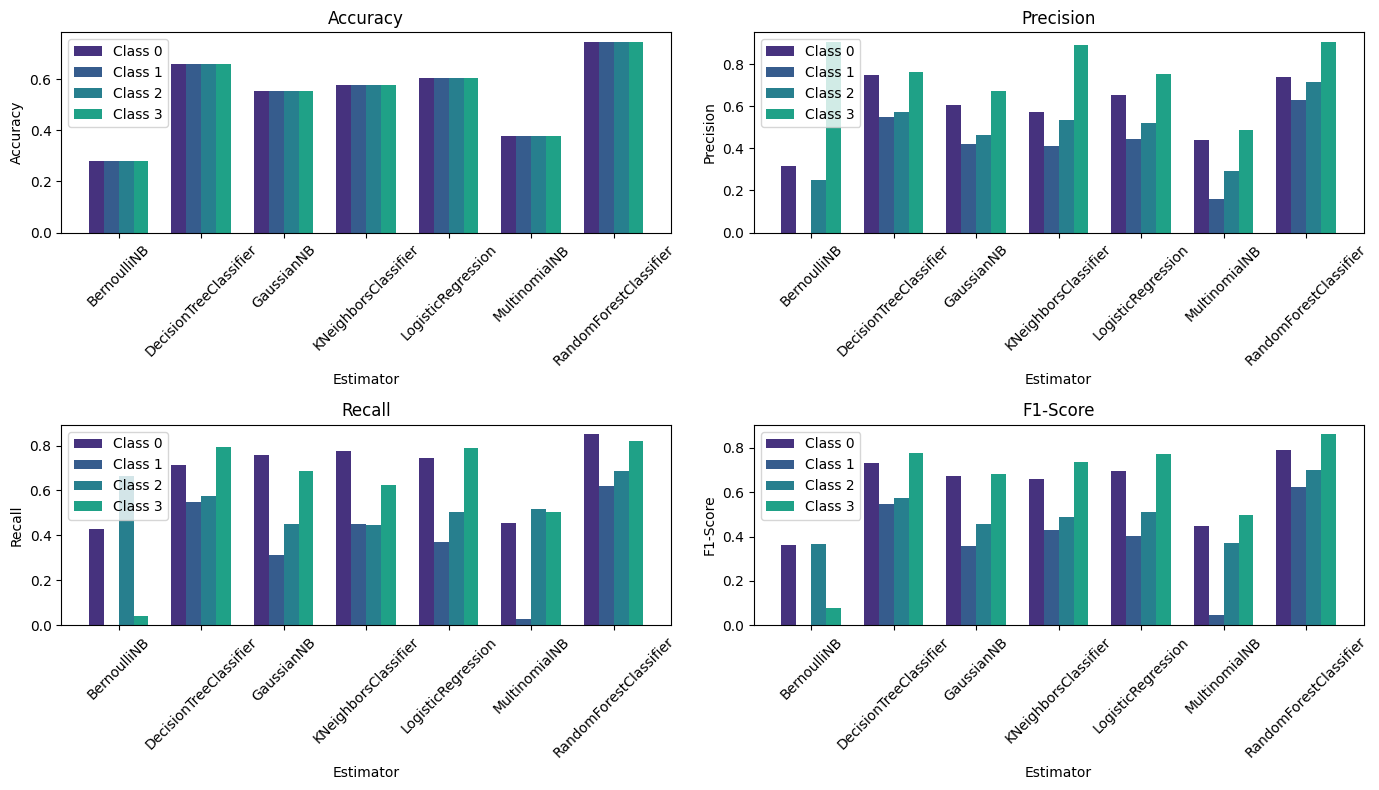

In [30]:
metrics = df_scores.columns.drop(['Estimator', 'Class'])

n_metrics = len(metrics)
n_cols = 2
n_rows = math.ceil(n_metrics / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 8))
axs = axs.flatten()

for j, metric in enumerate(metrics):

    pivot = df_scores.pivot(index="Estimator", columns="Class", values=metric)

    estims = pivot.index
    classes = pivot.columns

    x = np.arange(len(estims))
    width = 0.18

    ax = axs[j]

    for i, c in enumerate(classes):
        ax.bar(x + i*width, pivot[c], width, label=f"Class {c}")

    ax.set_xticks(x + width*(len(classes)-1)/2)
    ax.set_xticklabels(estims, rotation=45)
    ax.set_xlabel("Estimator")
    ax.set_ylabel(metric)
    ax.set_title(metric)

    ax.legend()

plt.tight_layout()
plt.show()

The best models based on these estimators is RandomForestClassifier, being especcially good at identifying the edge classes - A and D.

Models based on Naive Bayes overall performed quite poorly, especially MultinomialNB and BernoulliNB.

A for-all tendency is that the middle classes (B and C) are often mismatched, which may be caused by minor differences between them.

## **SHAP**

In [ ]:
import shap
shap.initjs()

### Dataset Classification

In [19]:
explainer = shap.Explainer(estimators2[0].predict_proba, X_train2)
shap_values = explainer(X_test2)

PermutationExplainer explainer: 2680it [02:58, 14.45it/s]                          


#### bar

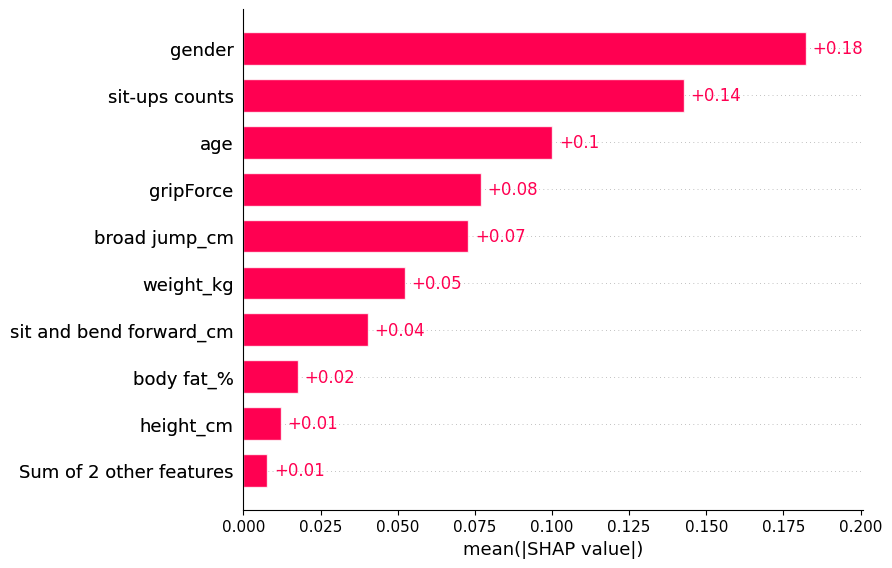

In [92]:
shap.plots.bar(shap_values[:, :, 0], max_display=10)

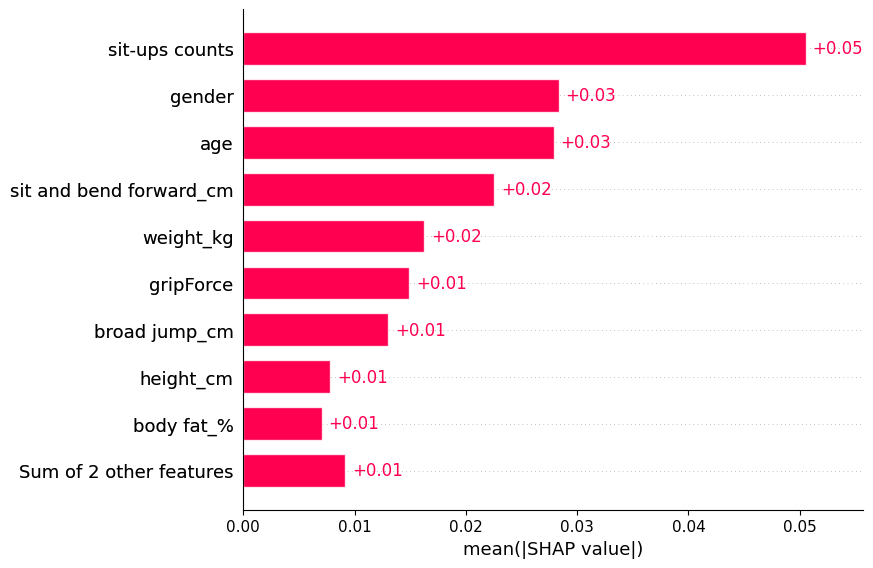

In [93]:
shap.plots.bar(shap_values[:, :, 1], max_display=10)

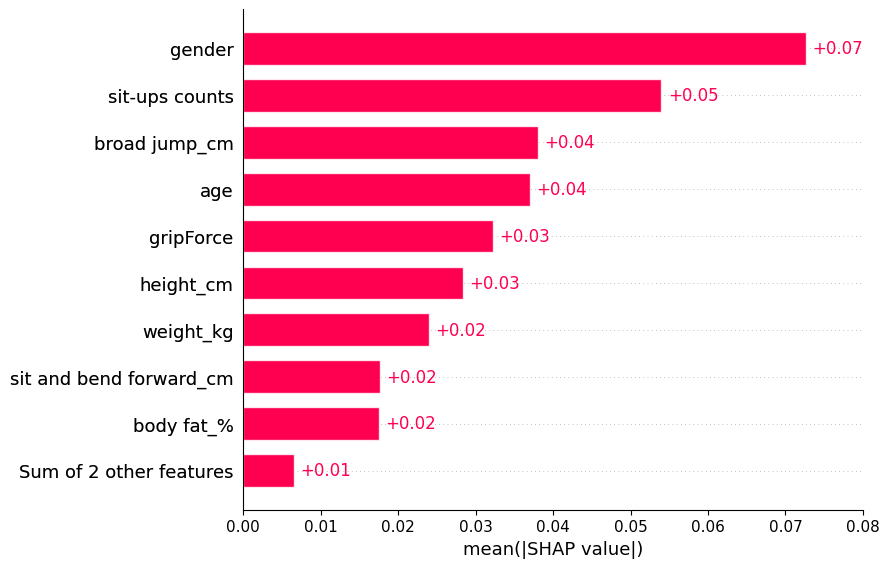

In [94]:
shap.plots.bar(shap_values[:, :, 2], max_display=10)

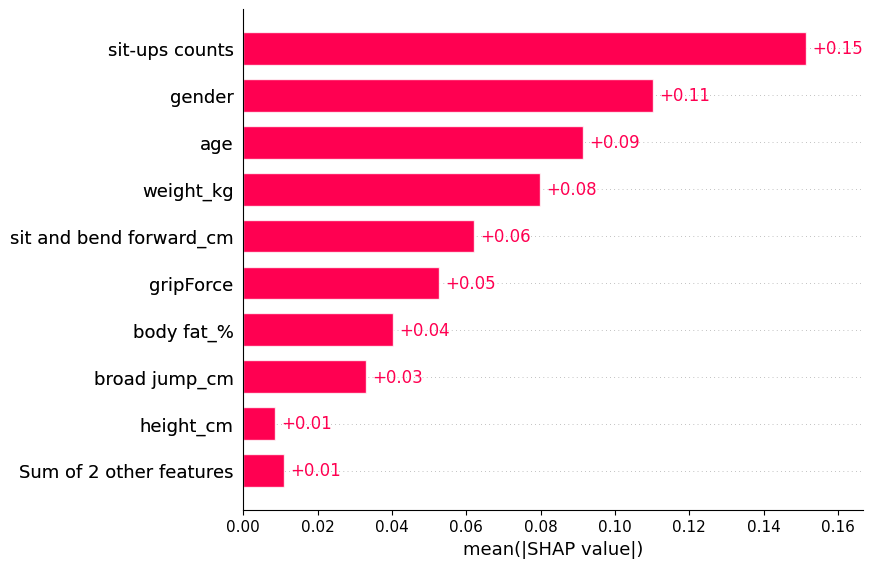

In [95]:
shap.plots.bar(shap_values[:, :, 3], max_display=10)

sit-ups, gender, and age are vital features in identifying

#### waterfall

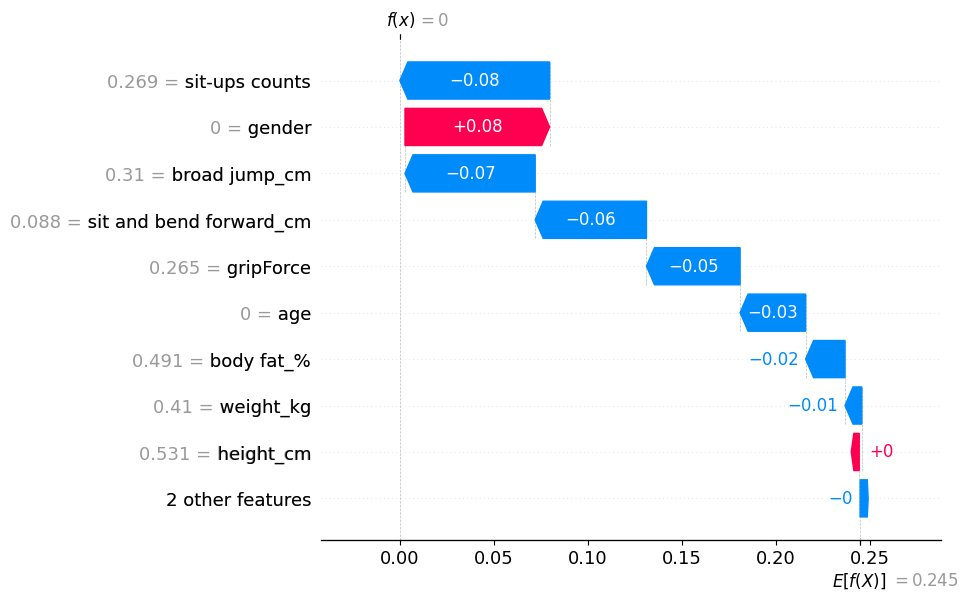

In [74]:
shap.plots.waterfall(shap_values[0, :, 0])

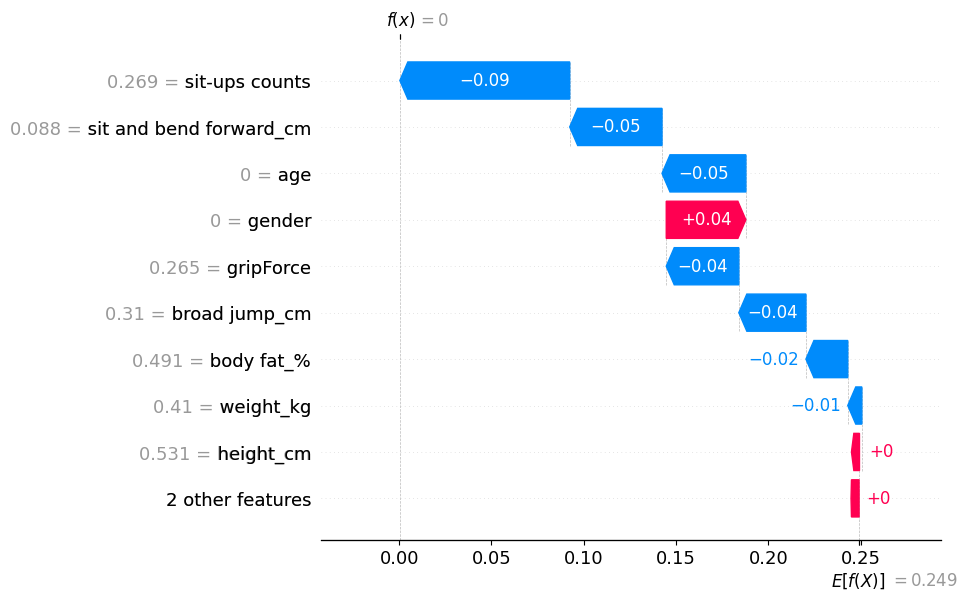

In [75]:
shap.plots.waterfall(shap_values[0, :, 1])

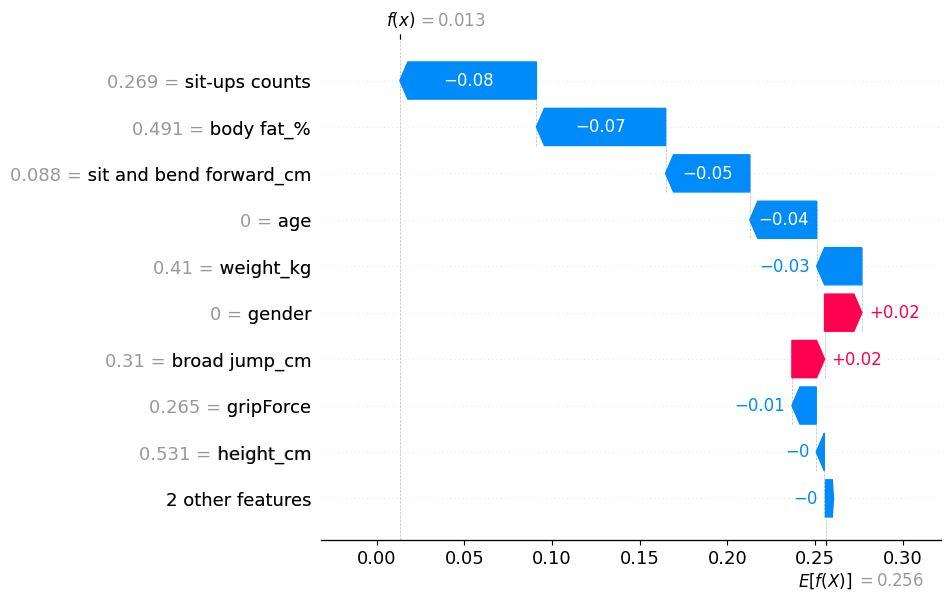

In [76]:
shap.plots.waterfall(shap_values[0, :, 2])

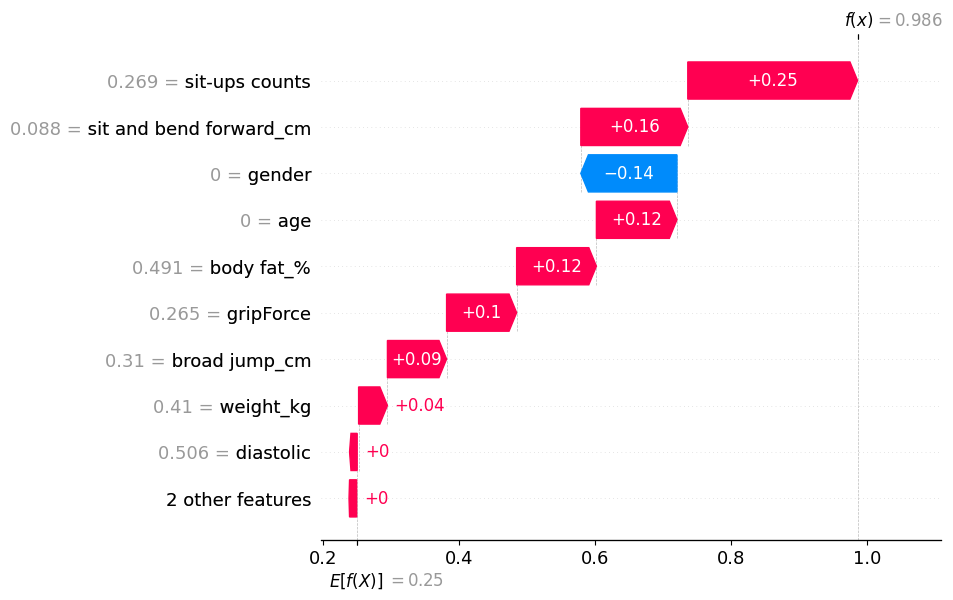

In [77]:
shap.plots.waterfall(shap_values[0, :, 3])

These waterfall plots show that sit-ups count are considered an important feature through all possible classes.

For top sportsmen, also the gender is important - overall, the model considers the males as being more sporty.

For least successful sportsmen the sit and bemd forward was considered important, as well as gender(again, but this time, females). Moreover, they play the main role in identifying the class.

#### beeswarm

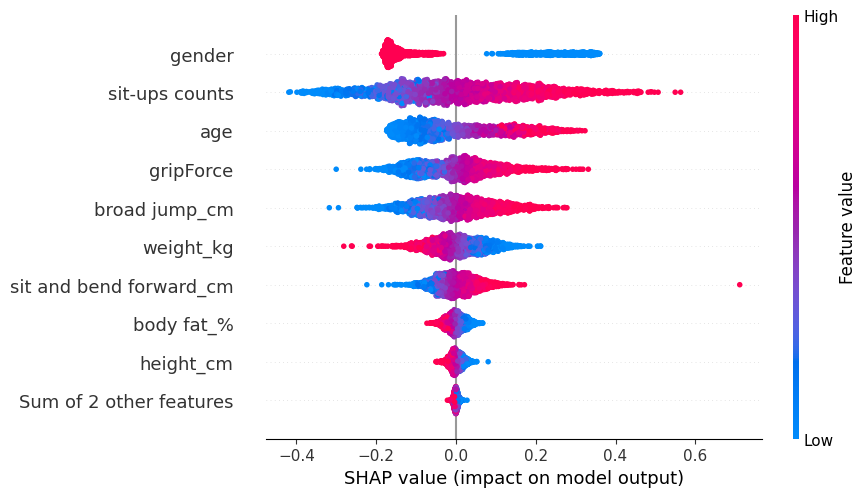

In [81]:
shap.plots.beeswarm(shap_values[:, :, 0])

It shows that males are rather good sportsmen, having a high number of sit-ups counts, being quite old, and having a big gripForce.

The weight, body fat, and height are small.

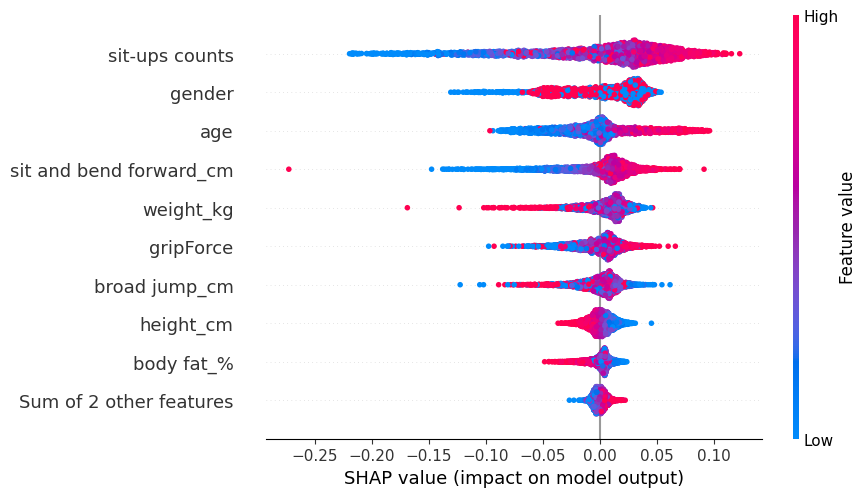

In [89]:
shap.plots.beeswarm(shap_values[:, :, 1])

This one is not as straightforward as previous one. However, we can state for sure that the number of sit-ups is still quite high, as well as sit and bend forward, and age.

The body fat is quite low, as well as height.

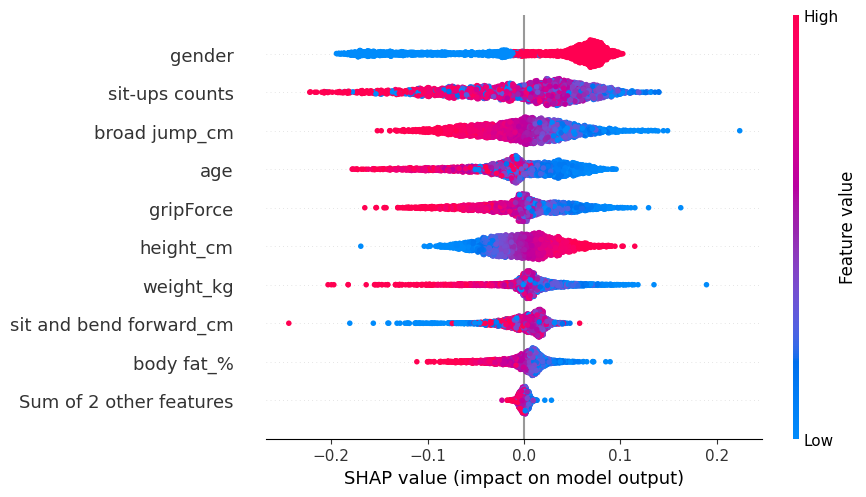

In [90]:
shap.plots.beeswarm(shap_values[:, :, 2])

For C class, the gender become inverse - mostly women, with medium-to-low sit-ups counts, young and quite tall.

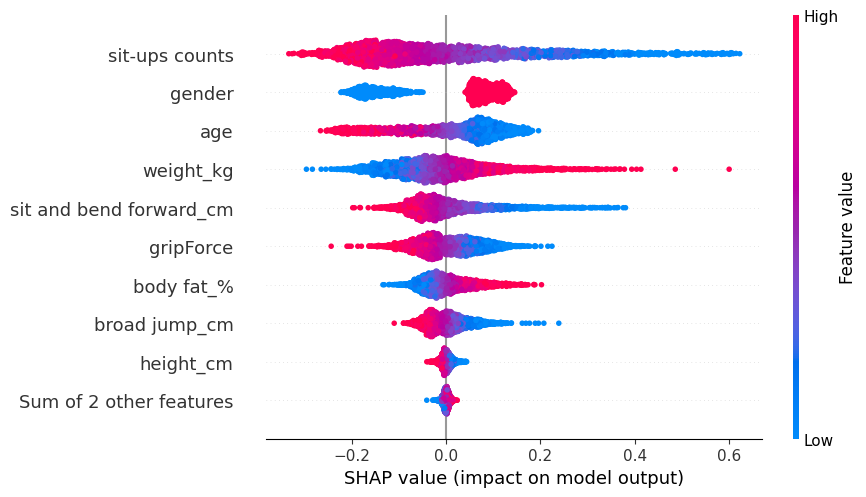

In [91]:
shap.plots.beeswarm(shap_values[:, :, 3])

The worst sportsmen are considered women with a small amount of sit-ups counts, short, and young, with a high weight, and increased body fat %.

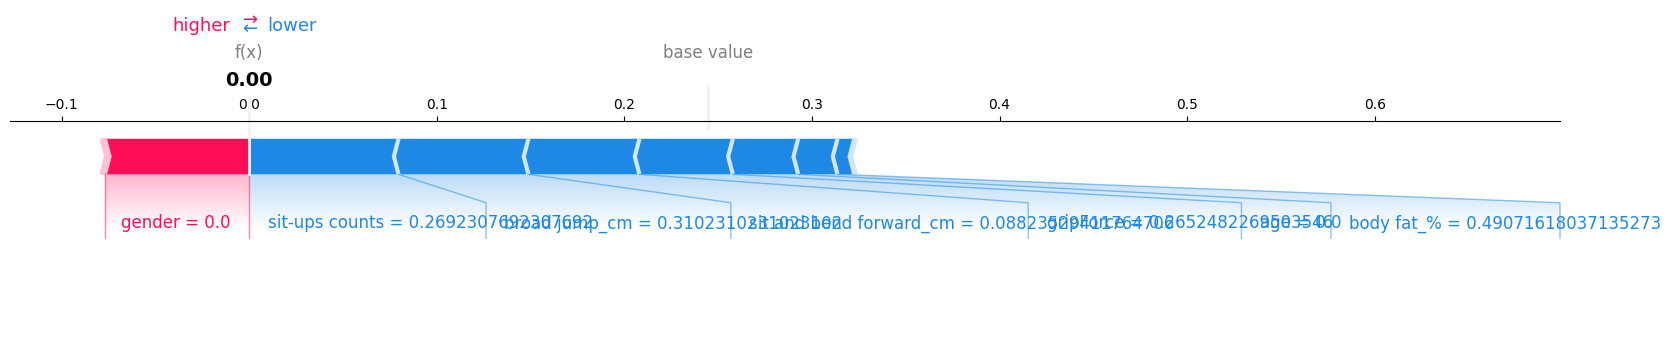

In [88]:
shap.plots.force(
    shap_values[0, :, 0],
    matplotlib=True,
    feature_names=X_test2.columns
)

As we see, the gender is the only negative influencing feature for class A,

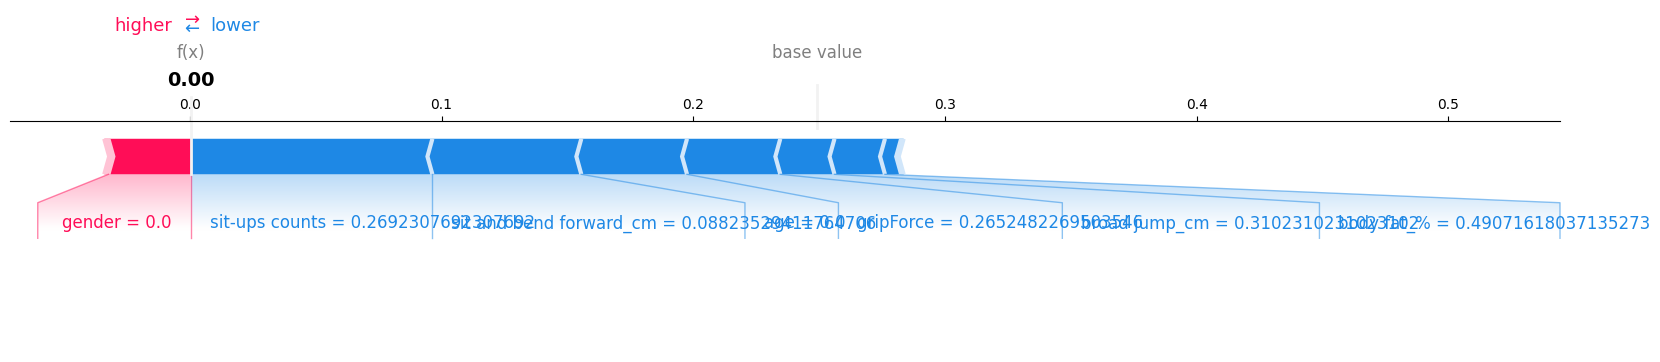

In [20]:
shap.plots.force(
    shap_values[0, :, 1],
    matplotlib=True,
    feature_names=X_test2.columns
)

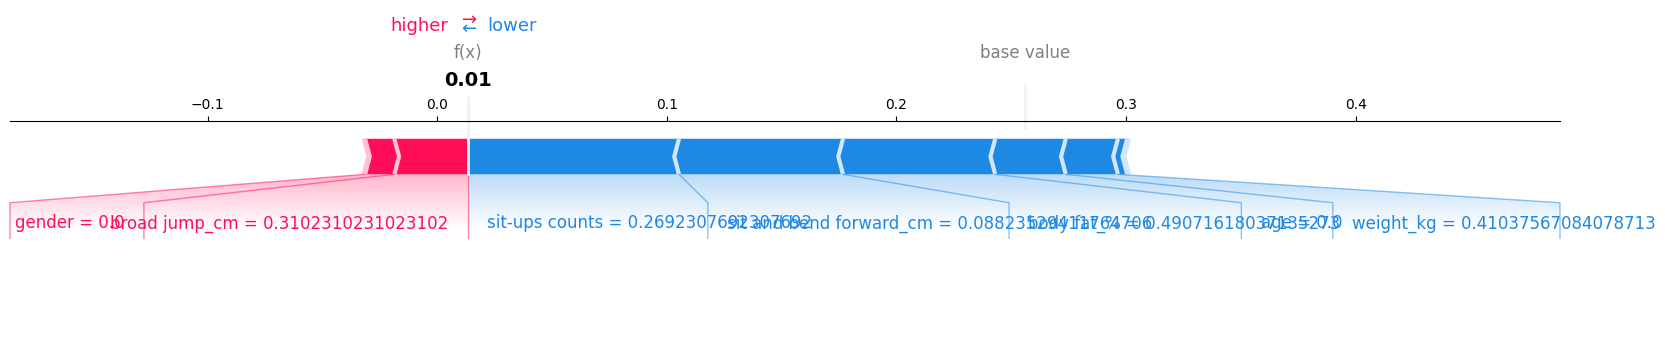

In [21]:
shap.plots.force(
    shap_values[0, :, 2],
    matplotlib=True,
    feature_names=X_test2.columns
)

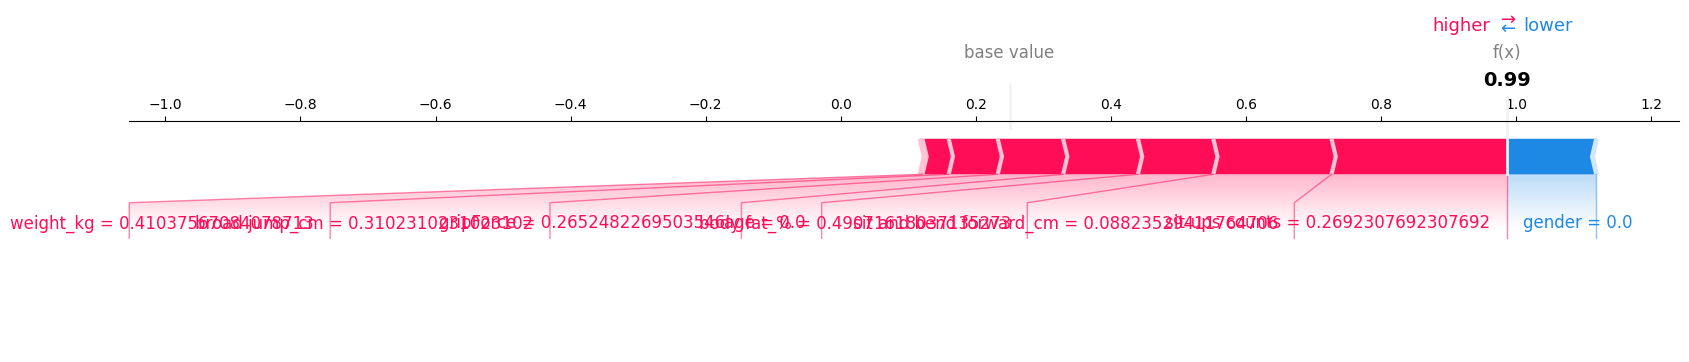

In [23]:
shap.plots.force(
    shap_values[0, :, 3],
    matplotlib=True,
    feature_names=X_test2.columns
)

Only for this class D the positions of features are inversed - only gender being positive and all others negative.

## **LIME**

### Dataset Regression

In [29]:
import lime.lime_tabular

In [30]:
explainer2 = lime.lime_tabular.LimeTabularExplainer(
  X_train1.values,
  feature_names = list(X_test1.columns),
  class_names = ['pm'],
  verbose=True, mode='regression')

In [32]:
exp = explainer2.explain_instance(X_test1.values[1], estimators[1].predict)
exp.show_in_notebook(show_table=True, show_all=False)

Intercept 54.87771359550691
Prediction_local [78.7680851]
Right: 81.46024698891209


As we see, the most important features are stator-related and motor_speed, positively contributing to the final result. As for i_d, it is still important, but negatively influencing the prediction.

#### Bad case

In [36]:
y_pred = estimators[1].predict(X_test1)

errors = np.abs(y_test1.values - y_pred)

i = np.argsort(errors)[-1]

print(f"\nIndex: {i}")
print(f"True value: {y_test1.iloc[i]}")
print(f"Predicted: {y_pred[i]}")
print(f"Error: {errors[i]}")
print("-" * 40)

exp = explainer2.explain_instance(
    X_test1.iloc[i].values,
    estimators[1].predict
)

exp.show_in_notebook(show_table=True)


Index: 2789
True value: 106.96668243408205
Predicted: 42.53909149169922
Error: 64.42759094238284
----------------------------------------
Intercept 56.07103695798756
Prediction_local [74.59309544]
Right: 42.53909149169922


The model produced a large error for this sample due to conflicting feature contributions. While features related stator pushed the prediction upwards, motor_speed was dragging it down, even though it should have been pulled up. It fails to generalize well for this region of the data, possibly due to insufficient similar training samples.

# **Conclusion**

Model's performance changes from the type of the problem - classification/regression, and uses various metrics. For regression, we use RMSE, MSE, MAE, while for classification there is Accuracy, Precision, F1-score, and Recall.

The majority of widespread models actually represent 'black boxes', so we need to use some tools to guess what is inside them.

SHAP and LIME are some of the model agnostic techniques used to find out. SHAP is based on Shapley values, when we "play" a game using features. On the other hand, LIME supposes that on some small parts the model can be interpreted as a linear one.

Overall, it is important not only to be able to choose and fine-tune the model, but also to interpret the results and understand what is going under-the-hood.